# Insurance Charges Linear Regression
Predict medical insurance charges using patient attributes (age, BMI, children, smoker status).

## 1. Import Libraries

In [1]:
# Core data manipulation and math libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: encoding, model selection, regression, and metrics
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Display plots inline in the notebook
%matplotlib inline

## 2. Load the Dataset

In [2]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('insuranceData.csv')

# Preview the first few rows to verify the data loaded correctly
df.head()

,age,bmi,children,smoker,charges
0,19,27.900,0,yes,16884.92400
1,18,33.770,1,no,1725.55230
2,28,33.000,3,no,4449.46200
3,33,22.705,0,no,21984.47061
4,32,28.880,0,no,3866.85520


In [3]:
# Check the shape, column names, data types, and missing values
print('Shape:', df.shape)
print()
df.info()
print()
print('Missing values per column:')
print(df.isnull().sum())

Shape: (1338, 5)

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   bmi       1338 non-null   float64
 2   children  1338 non-null   int64  
 3   smoker    1338 non-null   str    
 4   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(1)
memory usage: 52.4 KB

Missing values per column:
age         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64


In [4]:
# Summary statistics for numerical columns
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Exploratory Data Analysis

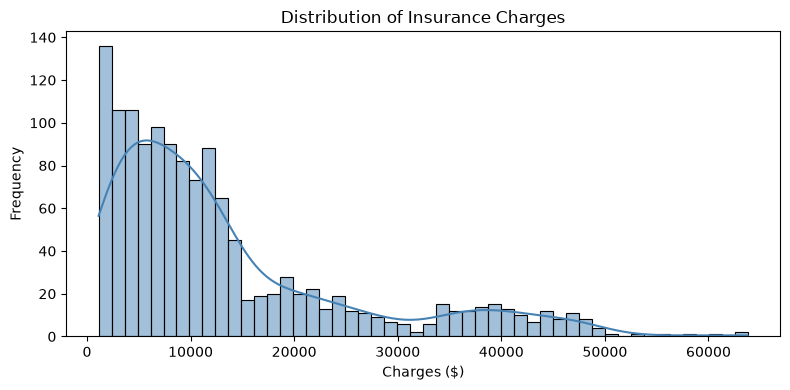

In [5]:
# Visualize the distribution of insurance charges
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/var/folders/zf/rgqg6trn25597cd583c21knw0000gn/T/ipykernel_1977/1132478076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


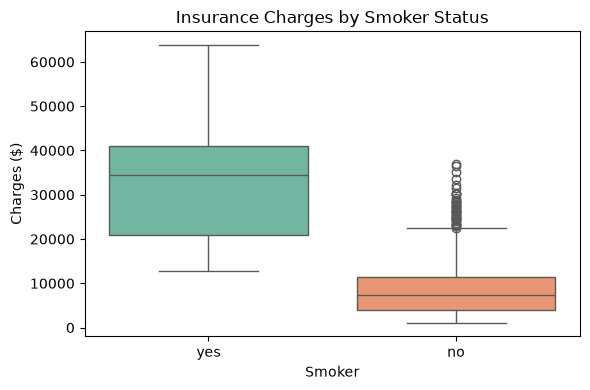

In [6]:
# Box plot showing how smoking status affects charges
plt.figure(figsize=(6, 4))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

## 4. Encode Categorical Data

The only categorical column in this dataset is **`smoker`** (yes/no).  
We apply:
- **`LabelEncoder`** — converts string labels to integer codes (0/1).
- **`OneHotEncoder`** — creates a binary dummy column for each category, avoiding ordinal assumptions.

In [7]:
# --- Step A: LabelEncoder ---
# Converts 'yes'/'no' to 1/0 in a new column so we can inspect the integer mapping
le = LabelEncoder()
df['smoker_label'] = le.fit_transform(df['smoker'])

print('LabelEncoder classes:', le.classes_)   # shows ['no', 'yes']
print('Sample smoker_label values:')
print(df[['smoker', 'smoker_label']].head(10))

LabelEncoder classes: ['no' 'yes']
Sample smoker_label values:
  smoker  smoker_label
0    yes             1
1     no             0
2     no             0
3     no             0
4     no             0
5     no             0
6     no             0
7     no             0
8     no             0
9     no             0


In [8]:
# --- Step B: OneHotEncoder ---
# sparse_output=False returns a dense numpy array instead of a sparse matrix
# drop='first' removes one dummy column to avoid multicollinearity (the dummy variable trap)
ohe = OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the 'smoker' column (needs 2-D input, hence double brackets)
smoker_ohe = ohe.fit_transform(df[['smoker']])

# Name the resulting column(s) and add to the DataFrame
ohe_col_names = ohe.get_feature_names_out(['smoker'])
ohe_df = pd.DataFrame(smoker_ohe, columns=ohe_col_names, index=df.index)

print('OneHotEncoder output columns:', list(ohe_col_names))
print('Sample OHE values:')
print(ohe_df.head(10))

OneHotEncoder output columns: ['smoker_yes']
Sample OHE values:
   smoker_yes
0         1.0
1         0.0
2         0.0
3         0.0
4         0.0
5         0.0
6         0.0
7         0.0
8         0.0
9         0.0


## 5. Prepare Feature Matrix (X) and Target Vector (y)

In [9]:
# Build the feature set using the numeric columns plus the OHE smoker column
# We use the OHE-encoded smoker column (preferred for linear regression)
X = pd.concat(
    [df[['age', 'bmi', 'children']], ohe_df],
    axis=1
)

# Target variable: the insurance charge we want to predict
y = df['charges']

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)
X.head()

Feature matrix shape: (1338, 4)
Target vector shape: (1338,)


,age,bmi,children,smoker_yes
0,19,27.900,0,1.0
1,18,33.770,1,0.0
2,28,33.000,3,0.0
3,33,22.705,0,0.0
4,32,28.880,0,0.0


## 6. Split Data into Training and Test Sets (85% / 15%)

In [10]:
# test_size=0.15 reserves 15% of records for testing;
# random_state=42 ensures the same split every run (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 1137
Test samples     : 201


## 7. Train the Linear Regression Model

In [11]:
# Instantiate and fit the model on the training data only
model = LinearRegression()
model.fit(X_train, y_train)

# Display the learned coefficients alongside feature names
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print('Intercept:', round(model.intercept_, 2))
coef_df

Intercept: -11924.06


,Feature,Coefficient
0,age,260.375528
1,bmi,316.747931
2,children,424.379432
3,smoker_yes,23760.702239


## 8. Evaluate the Model

In [12]:
# Generate predictions on the unseen test set
y_pred = model.predict(X_test)

# Calculate performance metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'Mean Squared Error  (MSE) : {mse:,.2f}')
print(f'Root Mean Sq Error (RMSE) : {rmse:,.2f}')
print(f'R² Score                  : {r2:.4f}')

Mean Squared Error  (MSE) : 31,416,287.36
Root Mean Sq Error (RMSE) : 5,605.02
R² Score                  : 0.7937


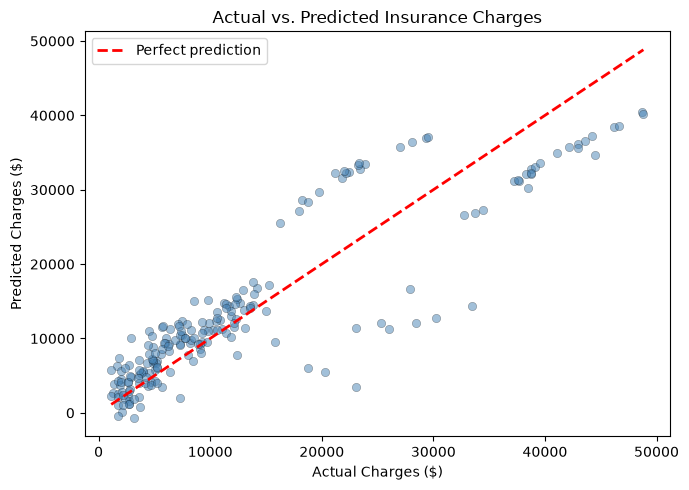

In [13]:
# Scatter plot: actual vs. predicted charges
# Points near the diagonal red line indicate accurate predictions
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs. Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

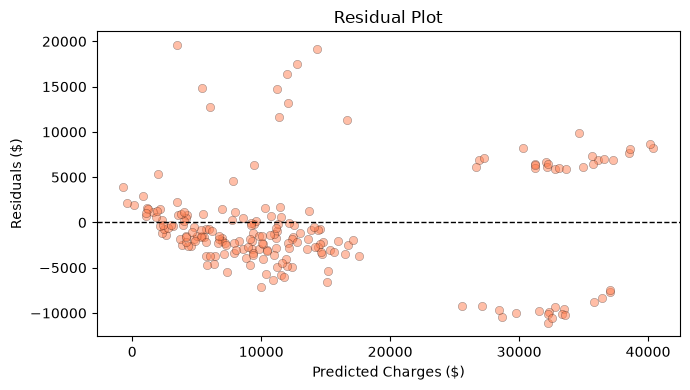

In [14]:
# Residual plot: residuals should be randomly scattered around 0
# A clear pattern would indicate the model is missing something
residuals = y_test - y_pred

plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='k', linewidths=0.3)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Predicted Charges ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

## 9. Summary

| Metric | Value |
|--------|-------|
| Training rows | 85% of dataset |
| Test rows | 15% of dataset |
| R² Score | see output above |
| RMSE | see output above |

**Key observations:**
- The `smoker_yes` coefficient is by far the largest, confirming that smoking is the strongest predictor of higher charges.
- Age and BMI also show positive relationships with charges.
- The residual plot reveals a curved pattern, suggesting the relationship is not purely linear — polynomial features or a log-transformed target could improve accuracy.